# Goal Mouth Placement

Visualise where shots end up on the goal face using `goalMouthCoordinates` (y = horizontal, z = height). Includes league-wide heatmap, penalty placement chart, goal placement by body part, and top scorers' finishing patterns.

In [1]:
from pathlib import Path
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as path_effects
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# ─── Path Configuration ──────────────────────────────────────────
RAW_MATCH_DIR  = Path('..') / 'data' / 'raw' / 'mt1cfl_2526' / 'raw_by_match'
DATA_DIR       = Path('..') / 'data' / 'processed'
FIGURES_DIR    = Path('..') / 'outputs' / 'figures'
FINAL_DIR      = Path('..') / 'outputs' / 'final_posts'
TEAM_LOGOS_DIR = DATA_DIR / 'team_logos'
FINAL_DIR.mkdir(parents=True, exist_ok=True)

# ─── Load All Shots ──────────────────────────────────────────
all_shots = []
for match_dir in sorted(RAW_MATCH_DIR.iterdir()):
    if not match_dir.is_dir():
        continue
    shots_file = match_dir / 'match_shots.csv'
    if shots_file.exists():
        try:
            df = pd.read_csv(shots_file)
            if len(df) > 0:
                df['match_id'] = match_dir.name
                all_shots.append(df)
        except Exception:
            continue

shots = pd.concat(all_shots, ignore_index=True)

# ─── Parse Goal Mouth Coordinates ─────────────────────────────
def parse_goal_mouth(coord_str):
    try:
        d = ast.literal_eval(coord_str)
        return float(d['y']), float(d['z'])
    except Exception:
        return np.nan, np.nan

def parse_player_info(player_str):
    try:
        d = ast.literal_eval(player_str)
        return int(d['id']), d.get('name', ''), d.get('shortName', '')
    except Exception:
        return np.nan, '', ''

shots[['gm_y_raw', 'gm_z_raw']] = shots['goalMouthCoordinates'].apply(
    lambda s: pd.Series(parse_goal_mouth(s))
)
shots[['player_id', 'player_name', 'player_short']] = shots['player'].apply(
    lambda s: pd.Series(parse_player_info(s))
)
shots = shots.dropna(subset=['gm_y_raw', 'gm_z_raw'])
shots['xg'] = pd.to_numeric(shots['xg'], errors='coerce').fillna(0)
shots['isGoal'] = (shots['shotType'] == 'goal').astype(int)

# Filter own goals
shots = shots[shots['situation'] != 'own-goal'].copy()

# ─── Normalize to Goal-Relative Coordinates ───────────────────
# Sofascore raw coords: posts at y ≈ 44.5/55.5, crossbar at z ≈ 38
# Normalize so 0 = left post, 100 = right post; 0 = ground, 100 = crossbar
GOAL_Y_LEFT  = 44.5   # left post in Sofascore coords
GOAL_Y_RIGHT = 55.5   # right post
GOAL_Z_BAR   = 38.0   # crossbar height

shots['gm_y'] = (shots['gm_y_raw'] - GOAL_Y_LEFT) / (GOAL_Y_RIGHT - GOAL_Y_LEFT) * 100
shots['gm_z'] = shots['gm_z_raw'] / GOAL_Z_BAR * 100

print(f'✅ Loaded {len(shots)} shots with goal-mouth coordinates')
print(f'   Goals: {(shots["shotType"]=="goal").sum()}')
print(f'   Saves: {(shots["shotType"]=="save").sum()}')
print(f'   Penalties: {(shots["situation"]=="penalty").sum()}')
print(f'\n   Normalized y range: {shots["gm_y"].min():.0f} – {shots["gm_y"].max():.0f}')
print(f'   Normalized z range: {shots["gm_z"].min():.0f} – {shots["gm_z"].max():.0f}')

✅ Loaded 2494 shots with goal-mouth coordinates
   Goals: 291
   Saves: 623
   Penalties: 34

   Normalized y range: -34 – 134
   Normalized z range: 0 – 157


In [2]:
# ─── Visual Constants ────────────────────────────────────────
BG_COLOR   = '#0a0a0a'
GOLD       = '#d4af37'
TEXT_WHITE = '#FFFFFF'
TEXT_GREY  = '#A0A0A0'
GOAL_RED   = '#e74c3c'
SAVE_ORANGE = '#f39c12'
MISS_GREY  = '#7f8c8d'
BLOCK_BLUE = '#3498db'
GREEN      = '#2ecc71'
POST_COLOR = '#cccccc'
NET_COLOR  = '#1a3a1a'

OUTCOME_COLORS = {
    'goal':  GOAL_RED,
    'save':  SAVE_ORANGE,
    'miss':  MISS_GREY,
    'block': BLOCK_BLUE,
    'post':  POST_COLOR,
}

def draw_goal_frame(ax, lw=3):
    """Draw a front-view goal frame on normalized coords (0-100 = goal frame).
    Shots outside 0-100 are saves/misses near posts or above the bar."""
    # Net background
    goal_rect = mpatches.Rectangle(
        (0, 0), 100, 100,
        linewidth=0, facecolor=NET_COLOR, zorder=1
    )
    ax.add_patch(goal_rect)
    # Posts
    ax.plot([0, 0], [0, 100], color=TEXT_WHITE, linewidth=lw + 1, zorder=2)
    ax.plot([100, 100], [0, 100], color=TEXT_WHITE, linewidth=lw + 1, zorder=2)
    # Crossbar
    ax.plot([0, 100], [100, 100], color=TEXT_WHITE, linewidth=lw + 2, zorder=2)
    # Ground line
    ax.plot([-15, 115], [0, 0], color='#3a7d44', linewidth=lw, zorder=2)
    ax.set_xlim(-20, 120)
    ax.set_ylim(-15, 130)
    ax.set_aspect(0.35)
    ax.axis('off')

✅ Saved: goal_mouth_heatmap.png


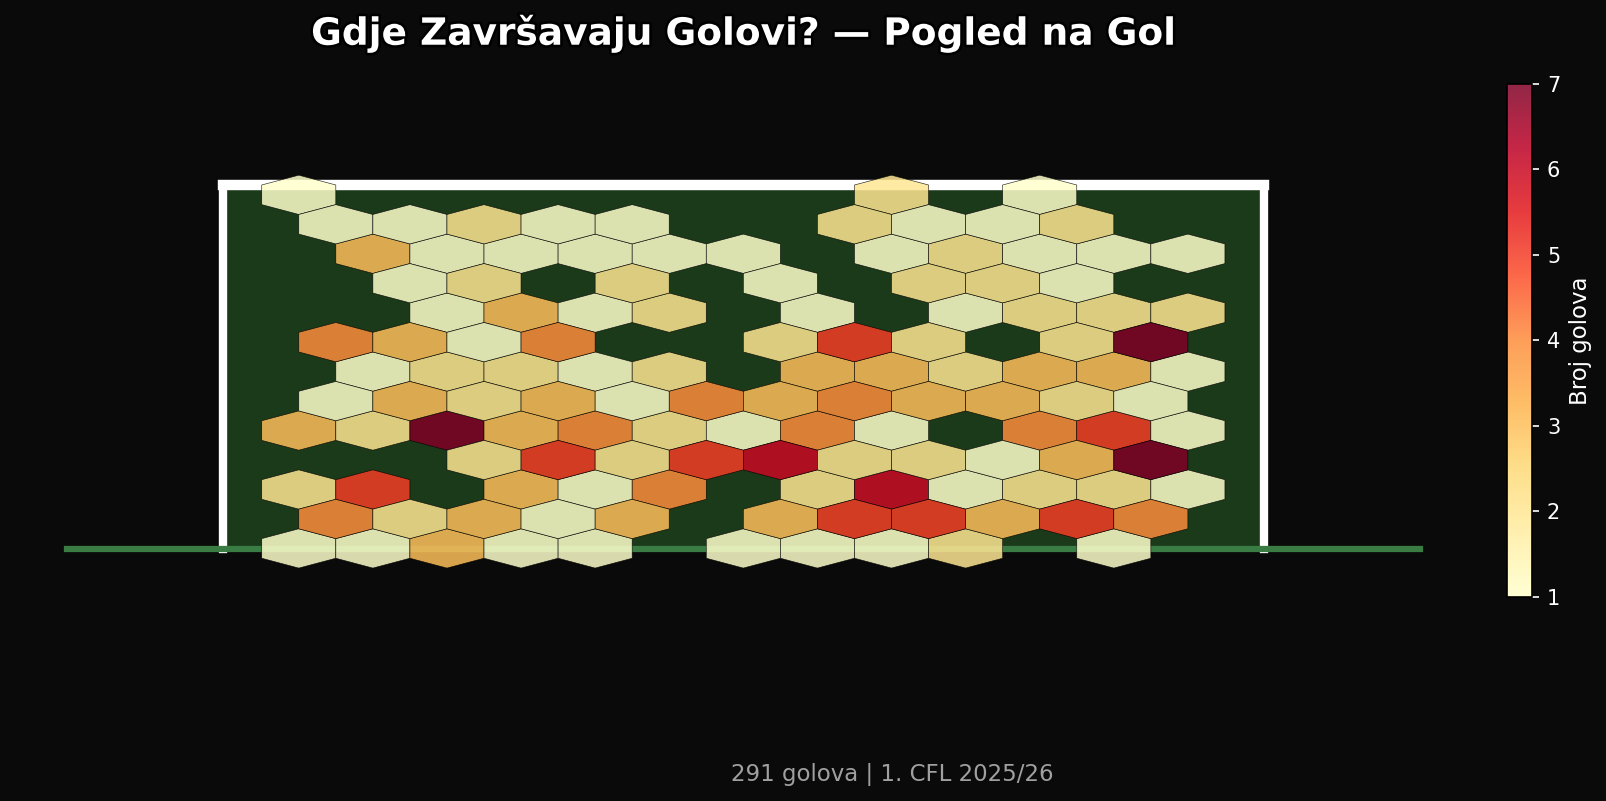

In [3]:
# ─── Figure 1: League-wide Goal Placement Heatmap ───────────
goals = shots[shots['shotType'] == 'goal'].copy()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(NET_COLOR)

draw_goal_frame(ax)

# Hexbin heatmap of all goals
hb = ax.hexbin(
    goals['gm_y'], goals['gm_z'],
    gridsize=12, cmap='YlOrRd', mincnt=1,
    edgecolors='black', linewidths=0.3,
    alpha=0.85, zorder=3
)

cb = fig.colorbar(hb, ax=ax, shrink=0.6, pad=0.02)
cb.set_label('Broj golova', color=TEXT_WHITE, fontsize=11)
cb.ax.yaxis.set_tick_params(color=TEXT_WHITE)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=TEXT_WHITE)

title = ax.set_title('Gdje Zavr\u0161avaju Golovi? \u2014 Pogled na Gol',
                      fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                        path_effects.Normal()])
fig.text(0.5, 0.01, f'{len(goals)} golova | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'goal_mouth_heatmap.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('\u2705 Saved: goal_mouth_heatmap.png')
plt.show()

✅ Saved: penalty_placement.png (34 penalties)


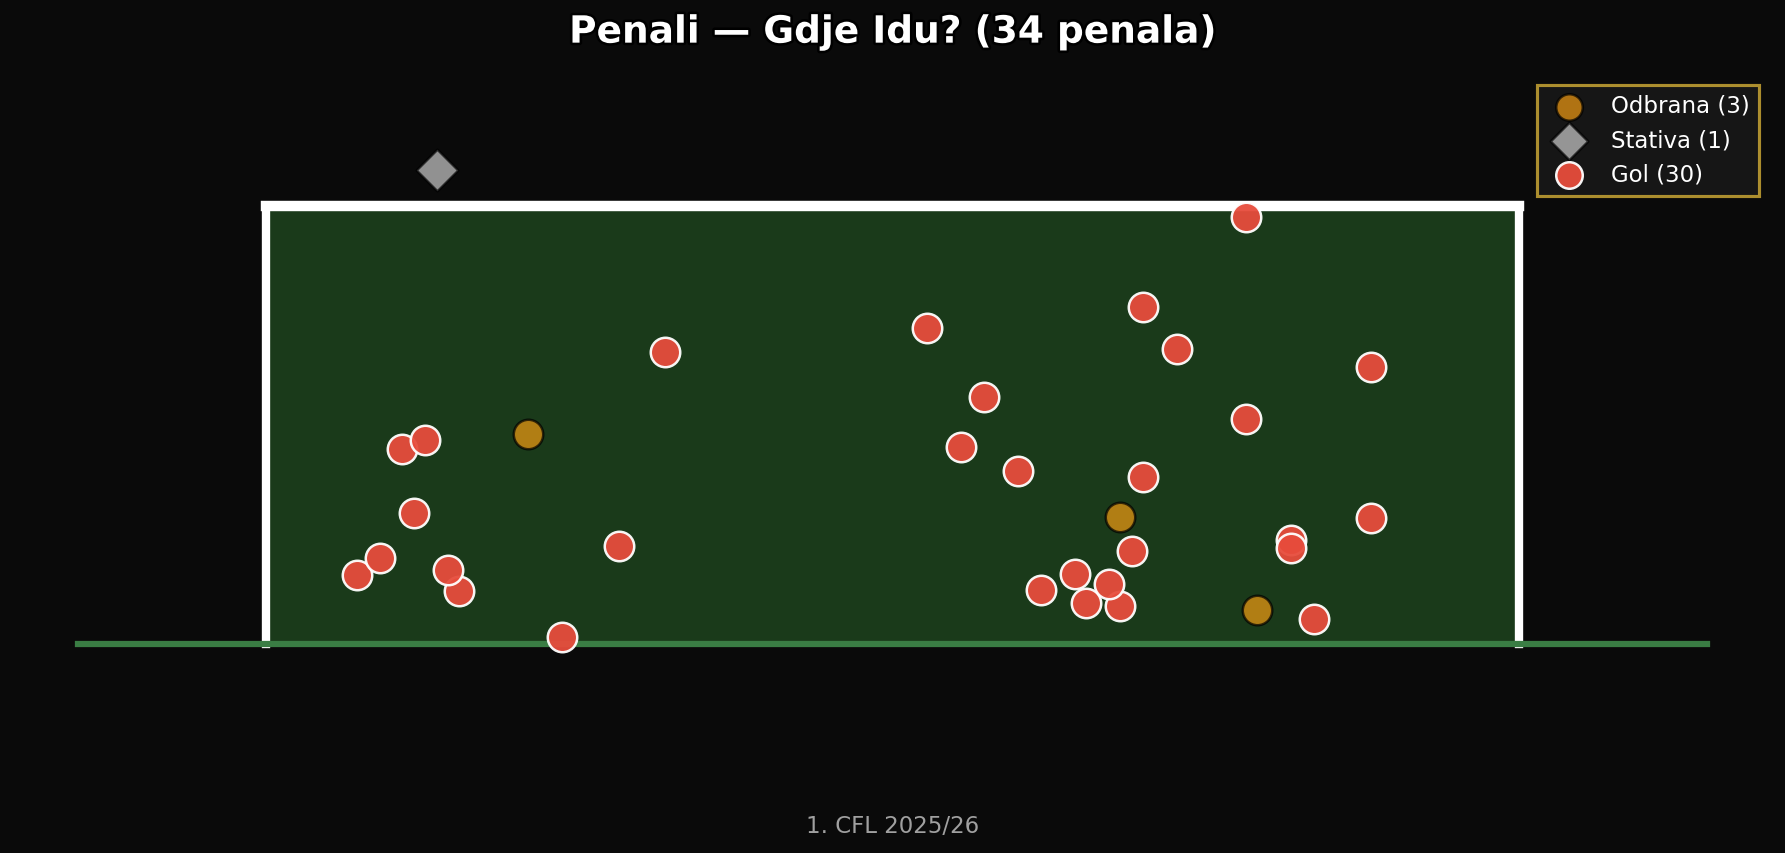

In [4]:
# ─── Figure 2: Penalty Placement Chart ───────────────────────
penalties = shots[shots['situation'] == 'penalty'].copy()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(NET_COLOR)

draw_goal_frame(ax)

# Plot each penalty
for outcome in ['save', 'post', 'goal']:
    subset = penalties[penalties['shotType'] == outcome]
    if len(subset) == 0:
        continue
    marker = 'o' if outcome != 'post' else 'D'
    edge = 'white' if outcome == 'goal' else 'black'
    alpha = 0.95 if outcome == 'goal' else 0.7
    zorder = 6 if outcome == 'goal' else 4
    ax.scatter(
        subset['gm_y'], subset['gm_z'],
        s=200, c=OUTCOME_COLORS[outcome], marker=marker,
        edgecolors=edge, linewidth=1.2, alpha=alpha, zorder=zorder,
        label={'goal': f'Gol ({len(subset)})', 'save': f'Odbrana ({len(subset)})',
               'post': f'Stativa ({len(subset)})'}[outcome]
    )

legend = ax.legend(loc='upper right', frameon=True, fancybox=False, fontsize=11,
                   edgecolor=GOLD, facecolor='#1a1a1a', labelcolor=TEXT_WHITE,
                   markerscale=0.9)
legend.get_frame().set_linewidth(1.5)

title = ax.set_title(f'Penali \u2014 Gdje Idu? ({len(penalties)} penala)',
                      fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                        path_effects.Normal()])
fig.text(0.5, 0.01, '1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'penalty_placement.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print(f'\u2705 Saved: penalty_placement.png ({len(penalties)} penalties)')
plt.show()

✅ Saved: goal_mouth_by_bodypart.png


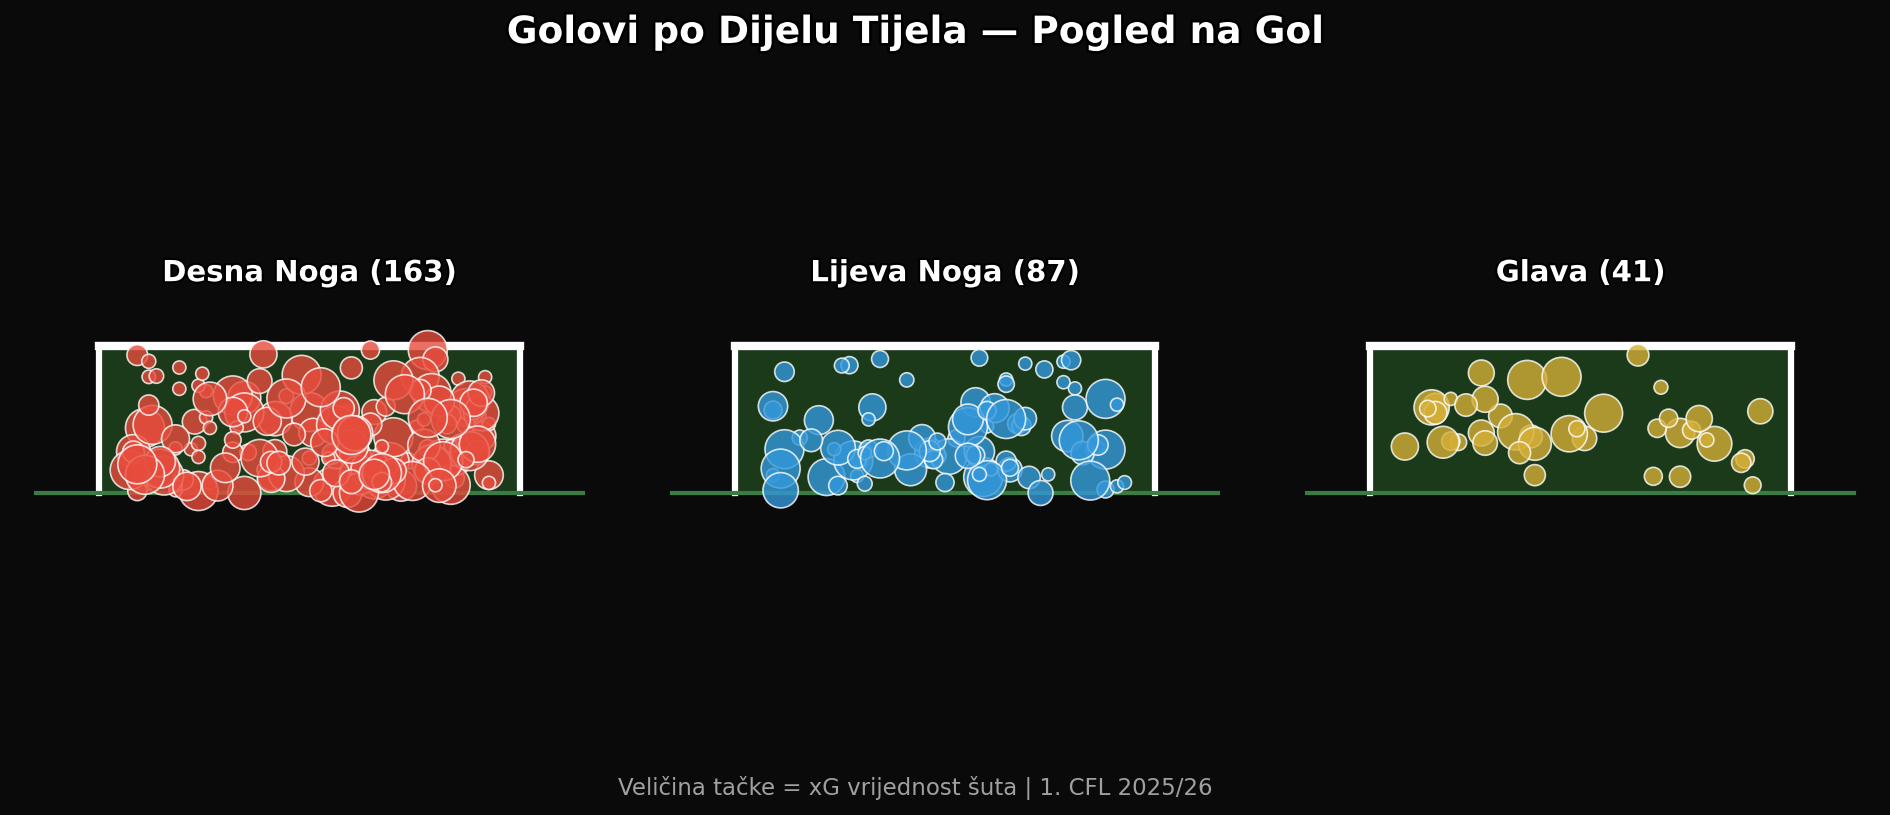

In [5]:
# ─── Figure 3: Goal Placement by Body Part (3 panels) ────────
body_parts = [
    ('right-foot', 'Desna Noga', GOAL_RED),
    ('left-foot', 'Lijeva Noga', BLOCK_BLUE),
    ('head', 'Glava', GOLD),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=150)
fig.patch.set_facecolor(BG_COLOR)

for ax, (bp, bp_label, color) in zip(axes, body_parts):
    ax.set_facecolor(NET_COLOR)
    draw_goal_frame(ax, lw=2)

    bp_goals = goals[goals['bodyPart'] == bp]
    ax.scatter(
        bp_goals['gm_y'], bp_goals['gm_z'],
        s=np.clip(bp_goals['xg'] * 600, 40, 350),
        c=color, edgecolors='white', linewidth=0.8,
        alpha=0.8, zorder=5
    )

    t = ax.set_title(f'{bp_label} ({len(bp_goals)})', fontsize=14, fontweight='bold',
                     color=TEXT_WHITE, pad=10)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                        path_effects.Normal()])

suptitle = fig.suptitle('Golovi po Dijelu Tijela \u2014 Pogled na Gol',
                         fontsize=18, fontweight='bold', color=TEXT_WHITE, y=1.02)
suptitle.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                           path_effects.Normal()])
fig.text(0.5, -0.02, 'Veli\u010dina ta\u010dke = xG vrijednost \u0161uta | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

fig.subplots_adjust(wspace=0.08)
plt.savefig(FIGURES_DIR / 'goal_mouth_by_bodypart.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('\u2705 Saved: goal_mouth_by_bodypart.png')
plt.show()

✅ Saved: goal_mouth_top_scorers.png


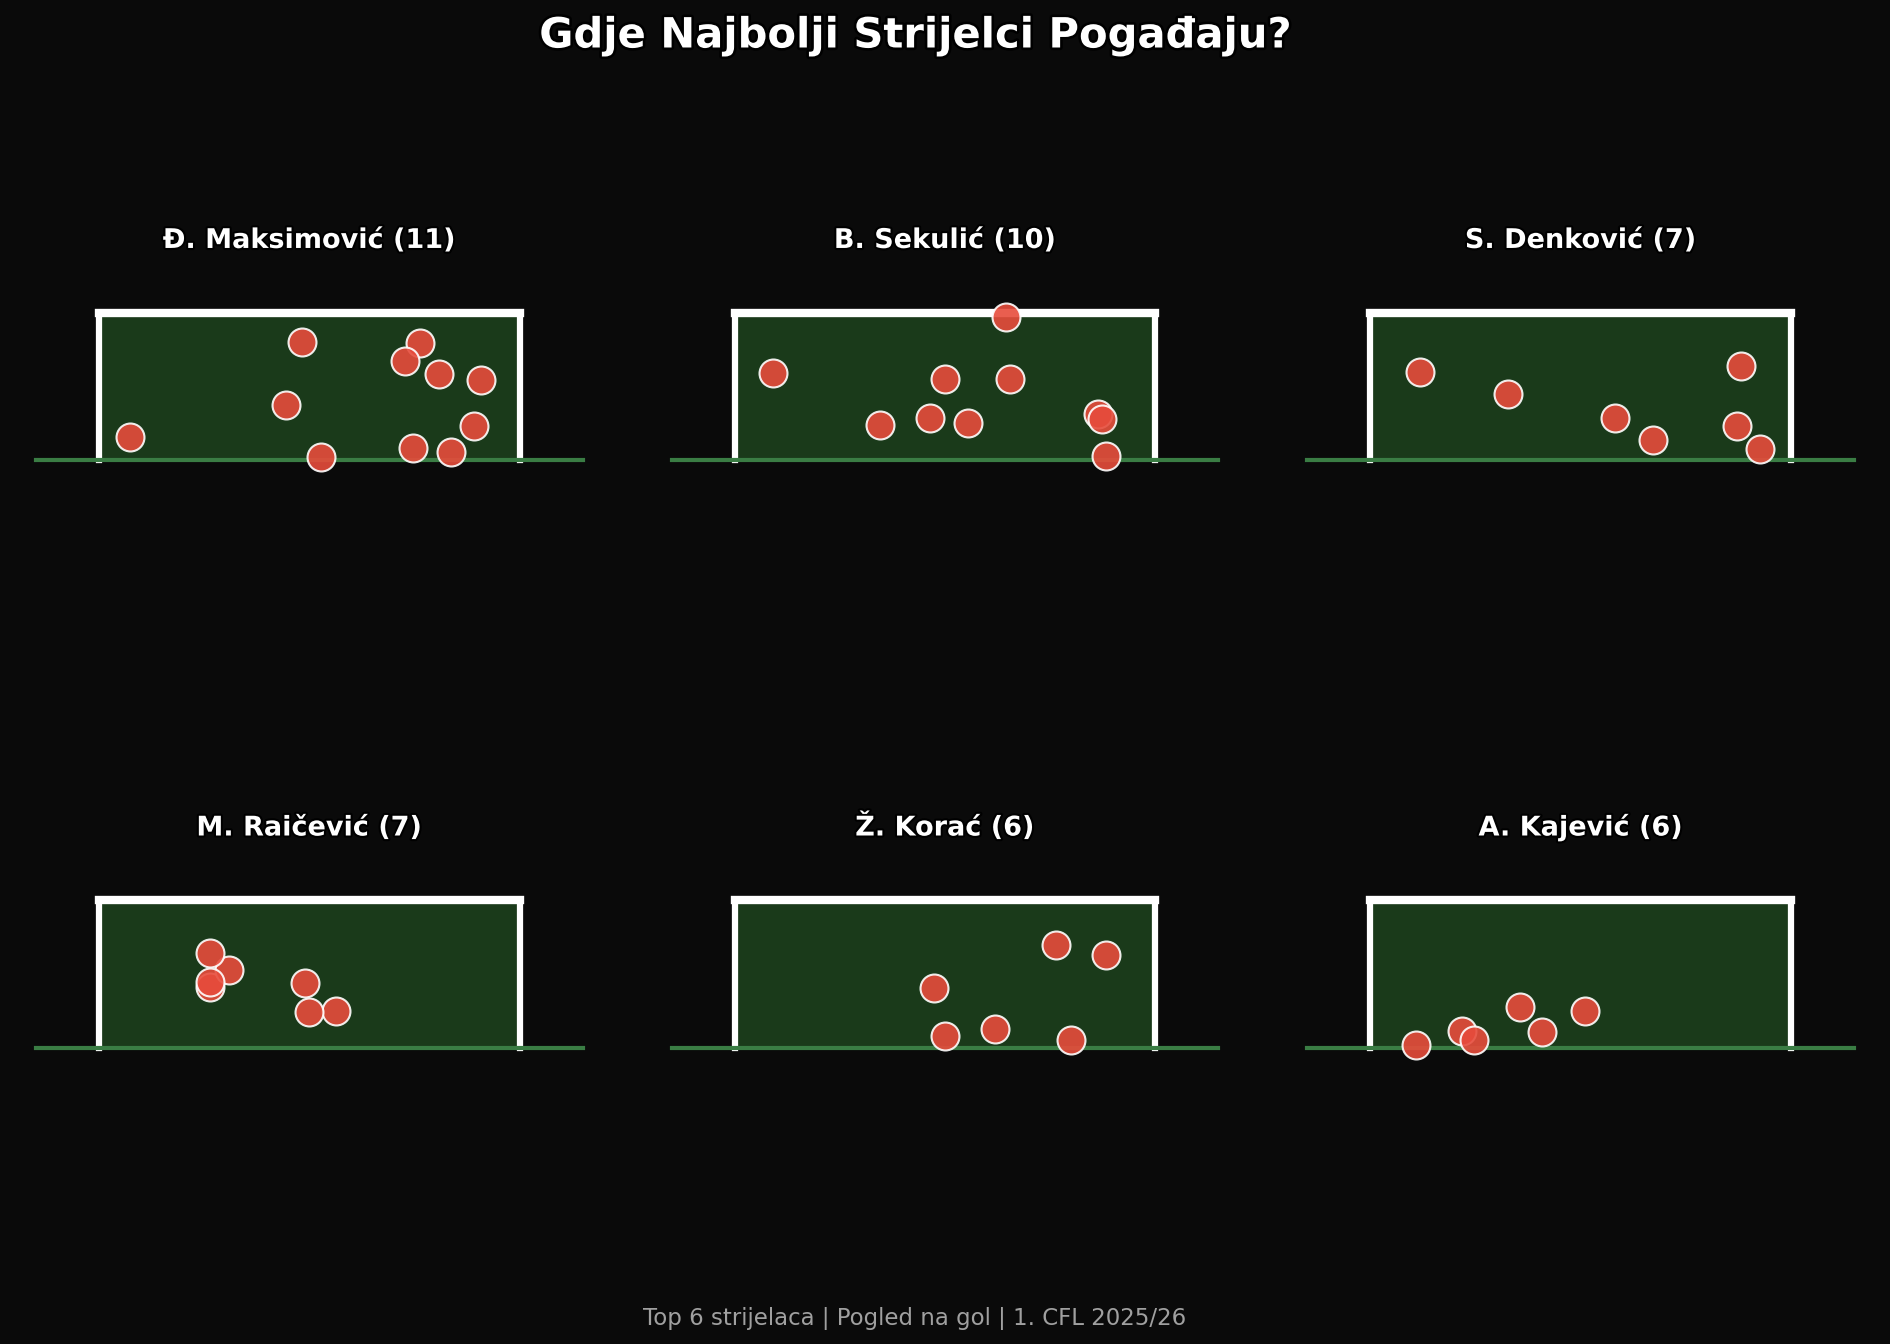

In [6]:
# ─── Figure 4: Top 6 Scorers — Where They Finish ────────────
scorer_counts = goals.groupby(['player_id', 'player_name', 'player_short']).size().reset_index(name='n_goals')
top6 = scorer_counts.nlargest(6, 'n_goals')

fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=150)
fig.patch.set_facecolor(BG_COLOR)

for ax, (_, row) in zip(axes.flat, top6.iterrows()):
    ax.set_facecolor(NET_COLOR)
    draw_goal_frame(ax, lw=2)

    pid = row['player_id']
    player_goals = goals[goals['player_id'] == pid]

    ax.scatter(
        player_goals['gm_y'], player_goals['gm_z'],
        s=180, c=GOAL_RED, edgecolors='white', linewidth=1.0,
        alpha=0.9, zorder=5
    )

    t = ax.set_title(f"{row['player_short']} ({int(row['n_goals'])})",
                     fontsize=13, fontweight='bold', color=TEXT_WHITE, pad=10)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                        path_effects.Normal()])

suptitle = fig.suptitle('Gdje Najbolji Strijelci Poga\u0111aju?',
                         fontsize=20, fontweight='bold', color=TEXT_WHITE, y=0.98)
suptitle.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                           path_effects.Normal()])
fig.text(0.5, 0.01, 'Top 6 strijelaca | Pogled na gol | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

fig.subplots_adjust(wspace=0.08, hspace=0.30)
plt.savefig(FIGURES_DIR / 'goal_mouth_top_scorers.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('\u2705 Saved: goal_mouth_top_scorers.png')
plt.show()

✅ Saved: goal_zone_conversion.png


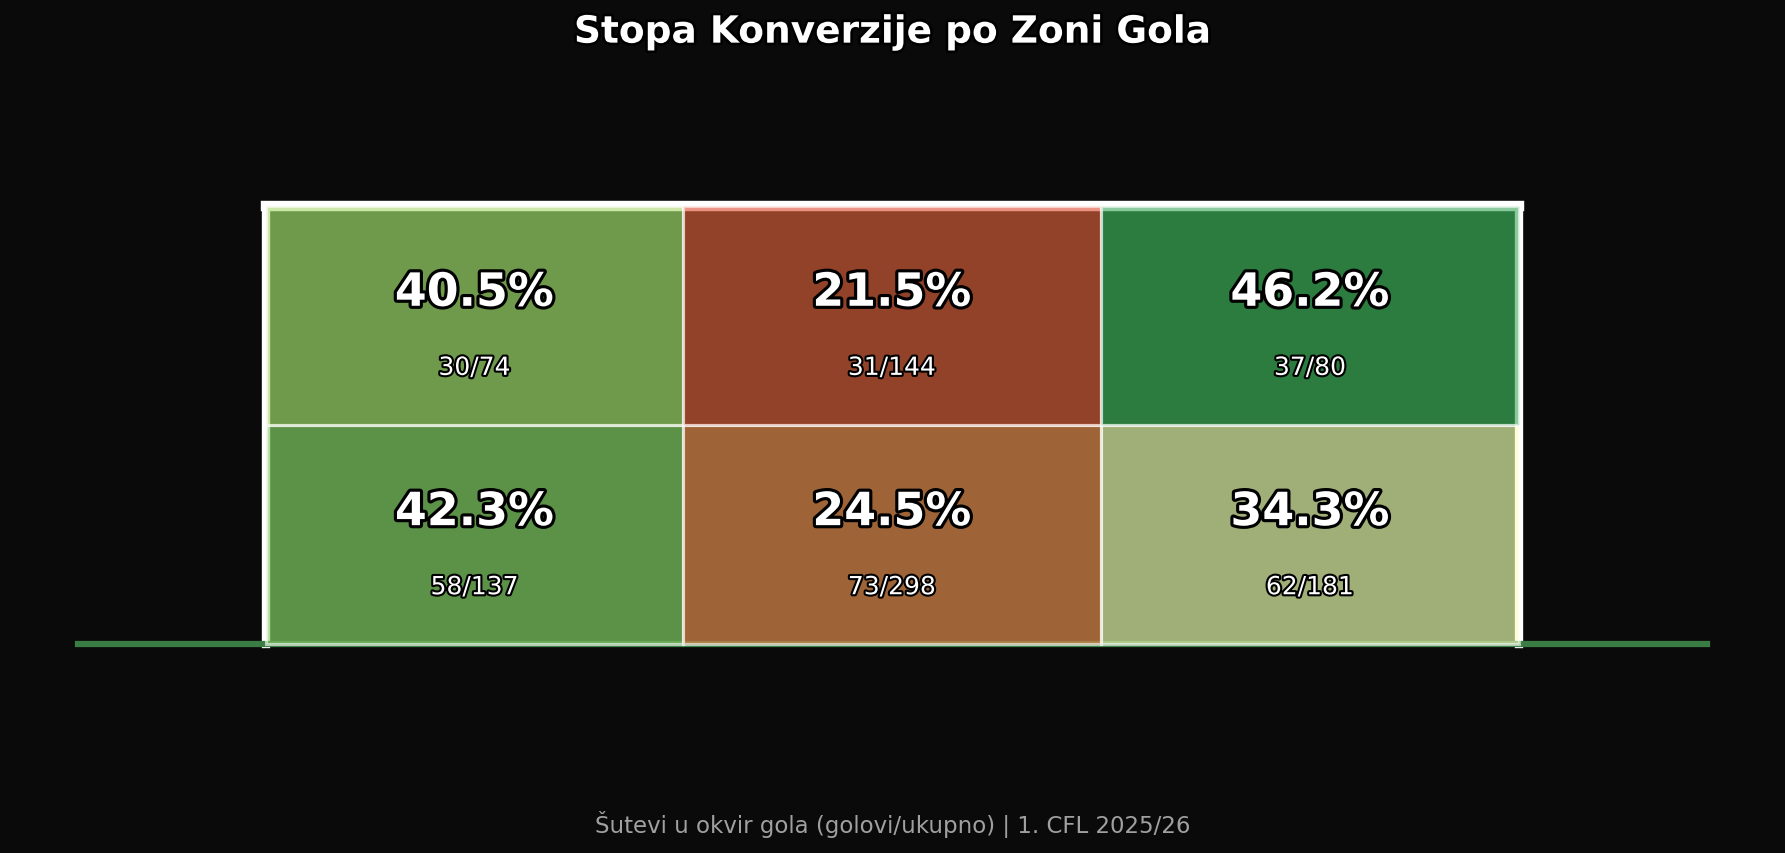

In [7]:
# ─── Figure 5: Shot Accuracy by Zone (where on the goal face) ───
# Divide goal into 6 zones (2 rows x 3 cols) and compute conversion rate
# Only use shots within the goal frame (0-100 on both axes)
all_on_target = shots[shots['shotType'].isin(['goal', 'save'])].copy()
all_on_target = all_on_target[
    (all_on_target['gm_y'] >= 0) & (all_on_target['gm_y'] <= 100) &
    (all_on_target['gm_z'] >= 0) & (all_on_target['gm_z'] <= 100)
]

# Zone boundaries (normalized coords: 0-100)
y_bins = [0, 33.3, 66.6, 100]
z_bins = [0, 50, 100]
y_labels = ['Lijevo', 'Centar', 'Desno']
z_labels = ['Nisko', 'Visoko']

all_on_target['y_zone'] = pd.cut(all_on_target['gm_y'], bins=y_bins, labels=y_labels, include_lowest=True)
all_on_target['z_zone'] = pd.cut(all_on_target['gm_z'], bins=z_bins, labels=z_labels, include_lowest=True)

zone_stats = (
    all_on_target.groupby(['z_zone', 'y_zone'], observed=False)
    .agg(total=('shotType', 'count'), goals=('isGoal', 'sum'))
    .reset_index()
)
zone_stats['conv_rate'] = (zone_stats['goals'] / zone_stats['total'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(NET_COLOR)
draw_goal_frame(ax)

# Draw zone rectangles with conversion rate
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

norm = Normalize(vmin=zone_stats['conv_rate'].min() - 5, vmax=zone_stats['conv_rate'].max() + 5)
cmap = plt.cm.RdYlGn  # Red (low) to Green (high)

y_edges = [0, 33.3, 66.6, 100]
z_edges = [0, 50, 100]

for _, zrow in zone_stats.iterrows():
    yi = y_labels.index(zrow['y_zone'])
    zi = z_labels.index(zrow['z_zone'])
    x0, x1 = y_edges[yi], y_edges[yi + 1]
    z0, z1 = z_edges[zi], z_edges[zi + 1]
    w, h = x1 - x0, z1 - z0

    color = cmap(norm(zrow['conv_rate']))
    rect = mpatches.Rectangle((x0, z0), w, h, facecolor=color, alpha=0.6,
                               edgecolor='white', linewidth=1.5, zorder=3)
    ax.add_patch(rect)

    cx, cz = x0 + w / 2, z0 + h / 2
    # Conversion rate
    t = ax.text(cx, cz + 5, f'{zrow["conv_rate"]}%', fontsize=22, fontweight='bold',
               color=TEXT_WHITE, ha='center', va='center', zorder=5)
    t.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                        path_effects.Normal()])
    # Count
    t2 = ax.text(cx, cz - 12, f'{int(zrow["goals"])}/{int(zrow["total"])}',
                fontsize=12, color=TEXT_WHITE, ha='center', va='center', zorder=5)
    t2.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                         path_effects.Normal()])

title = ax.set_title('Stopa Konverzije po Zoni Gola',
                      fontsize=18, fontweight='bold', color=TEXT_WHITE, pad=15)
title.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                        path_effects.Normal()])
fig.text(0.5, 0.01, 'Šutevi u okvir gola (golovi/ukupno) | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'goal_zone_conversion.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: goal_zone_conversion.png')
plt.show()

✅ Saved: penalty_placement.png (1080×1350px)


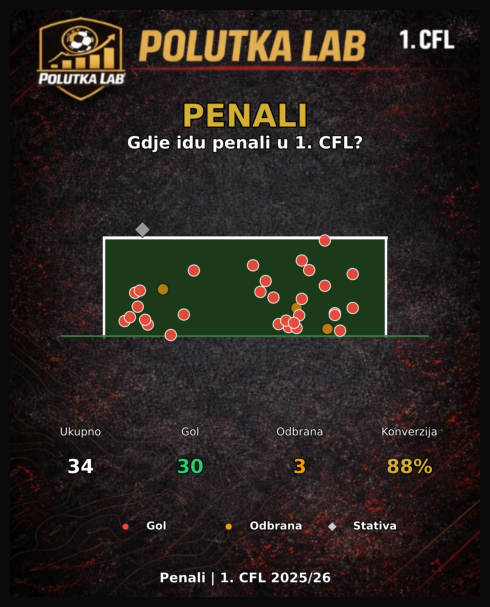

In [8]:
# ─── Instagram Post: Penalty Placement ──────────────────────
INSTAGRAM_SIZE = (1080, 1350)
BKG_PATH = FIGURES_DIR / 'background.png'

background = Image.open(BKG_PATH)
if background.size != INSTAGRAM_SIZE:
    background = background.resize(INSTAGRAM_SIZE, Image.Resampling.LANCZOS)
background_array = np.array(background)

fig = plt.figure(figsize=(10.8, 13.5), dpi=100)

# Background
ax_bg = fig.add_axes([0, 0, 1, 1], zorder=0)
ax_bg.imshow(background_array, aspect='auto', extent=[0, 1, 0, 1])
ax_bg.axis('off')

# ── Title ──
t1 = ax_bg.text(0.5, 0.84, 'PENALI',
                transform=fig.transFigure, fontsize=52, fontweight='bold',
                color=GOLD, ha='center', va='top')
t1.set_path_effects([path_effects.Stroke(linewidth=4, foreground='black'),
                     path_effects.Normal()])

t2 = ax_bg.text(0.5, 0.785, 'Gdje idu penali u 1. CFL?',
                transform=fig.transFigure, fontsize=28, fontweight='bold',
                color=TEXT_WHITE, ha='center', va='top')
t2.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                     path_effects.Normal()])

# ── Goal frame with penalty dots ──
ax_goal = fig.add_axes([0.08, 0.35, 0.84, 0.38])
ax_goal.set_facecolor(NET_COLOR)
draw_goal_frame(ax_goal, lw=3)

penalties = shots[shots['situation'] == 'penalty'].copy()

for outcome in ['save', 'post', 'goal']:
    subset = penalties[penalties['shotType'] == outcome]
    if len(subset) == 0:
        continue
    marker = 'o' if outcome != 'post' else 'D'
    edge = 'white' if outcome == 'goal' else 'black'
    alpha = 0.95 if outcome == 'goal' else 0.7
    zorder = 6 if outcome == 'goal' else 4
    ax_goal.scatter(
        subset['gm_y'], subset['gm_z'],
        s=350, c=OUTCOME_COLORS[outcome], marker=marker,
        edgecolors=edge, linewidth=1.5, alpha=alpha, zorder=zorder,
    )

# ── Stats bar ──
n_scored = (penalties['shotType'] == 'goal').sum()
n_saved = (penalties['shotType'] == 'save').sum()
n_post = (penalties['shotType'] == 'post').sum()
conv_rate = n_scored / len(penalties) * 100 if len(penalties) > 0 else 0

stat_items = [
    ('Ukupno', str(len(penalties)), TEXT_WHITE),
    ('Gol', str(n_scored), GREEN),
    ('Odbrana', str(n_saved), SAVE_ORANGE),
    ('Konverzija', f'{conv_rate:.0f}%', GOLD),
]
stats_y_label = 0.28
stats_y_val   = 0.22
n_stats = len(stat_items)
stats_total_width = 0.70
stats_start = 0.5 - stats_total_width / 2
stats_spacing = stats_total_width / (n_stats - 1)

for j, (label, val, val_color) in enumerate(stat_items):
    sx = stats_start + j * stats_spacing
    lbl = ax_bg.text(sx, stats_y_label, label,
                     transform=fig.transFigure, fontsize=18, color=TEXT_WHITE,
                     ha='center', va='center')
    lbl.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                          path_effects.Normal()])
    v = ax_bg.text(sx, stats_y_val, val,
                   transform=fig.transFigure, fontsize=32, fontweight='bold',
                   color=val_color, ha='center', va='center')
    v.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                        path_effects.Normal()])

# ── Legend ──
legend_y = 0.12
legend_items = [('Gol', GOAL_RED, 'o'), ('Odbrana', SAVE_ORANGE, 'o'), ('Stativa', POST_COLOR, 'D')]
legend_spacing = 0.22
total_lw = (len(legend_items) - 1) * legend_spacing
lx_start = 0.5 - total_lw / 2
for j, (lbl, col, mkr) in enumerate(legend_items):
    lx = lx_start + j * legend_spacing
    ax_bg.scatter(lx - 0.035, legend_y, s=120, c=col, marker=mkr,
                  transform=fig.transFigure, edgecolors='black',
                  linewidth=0.6, zorder=10, clip_on=False)
    ltxt = ax_bg.text(lx + 0.01, legend_y, lbl,
                      transform=fig.transFigure, fontsize=18, fontweight='bold',
                      color=TEXT_WHITE, va='center')
    ltxt.set_path_effects([path_effects.Stroke(linewidth=2.5, foreground='black'),
                           path_effects.Normal()])

# Footer
ftxt = ax_bg.text(0.5, 0.025, 'Penali | 1. CFL 2025/26',
                  transform=fig.transFigure, fontsize=22, fontweight='bold',
                  color=TEXT_WHITE, ha='center')
ftxt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                       path_effects.Normal()])

slide_path = FINAL_DIR / 'penalty_placement.png'
fig.savefig(slide_path, dpi=100, format='png')
plt.close(fig)

img = Image.open(slide_path)
w, h = img.size
print(f'\u2705 Saved: {slide_path.name} ({w}\u00d7{h}px)')

# Preview
fig_p, ax_p = plt.subplots(figsize=(5, 6.25))
ax_p.imshow(img)
ax_p.axis('off')
fig_p.patch.set_facecolor(BG_COLOR)
plt.tight_layout()
plt.show()

## Preferred Foot × Penalty Analysis

How does a kicker's preferred foot affect where they place penalties?
- **Otvorena noga** (open foot / natural side): inside-of-foot strike going to the kicker's natural side
- **Zatvorena noga** (closed foot / across body): strike going across the body

Also: do goalkeepers make more saves diving to their dominant side?

In [9]:
# ─── Load Preferred Foot & Build Penalty Dataset ─────────────
import json

players_meta = pd.read_csv(DATA_DIR / 'players_metadata.csv')
foot_map = players_meta.set_index('id')['preferredFoot'].to_dict()

# Filter penalties and attach kicker's preferred foot
pens = shots[shots['situation'] == 'penalty'].copy()
pens['preferredFoot'] = pens['player_id'].map(foot_map)

# ── Build goalkeeper lookup from lineups ──
gk_lookup = {}  # (match_id_str, side) → player_id of starting GK
for match_dir in sorted(RAW_MATCH_DIR.iterdir()):
    if not match_dir.is_dir():
        continue
    lf = match_dir / 'lineups.json'
    if lf.exists():
        with open(lf, encoding='utf-8') as f:
            ld = json.load(f)
        for side in ('home', 'away'):
            for p in ld.get(side, {}).get('players', []):
                if p.get('position') == 'G' and not p.get('substitute', False):
                    pid = p.get('player', {}).get('id')
                    if pid:
                        gk_lookup[(match_dir.name, side)] = pid

# Map opposing GK for each penalty
pens['_is_home'] = pens['isHome'].astype(str).str.lower() == 'true'
pens['opposing_gk_id'] = pens.apply(
    lambda r: gk_lookup.get((str(r['match_id']), 'away' if r['_is_home'] else 'home')), axis=1
)
pens['gk_foot'] = pens['opposing_gk_id'].map(foot_map)

# ── Classify kicker direction: open vs closed foot ──
# Coordinate system (confirmed from raw data):
#   gm_y = 0 (left of plot)  = kicker's RIGHT side of goal
#   gm_y = 100 (right of plot) = kicker's LEFT side of goal
# Right-foot open (inside of foot) → kicker's left → high gm_y
# Left-foot open  (inside of foot) → kicker's right → low gm_y

def classify_kicker_side(row):
    foot, y = row.get('preferredFoot'), row.get('gm_y')
    if pd.isna(y) or pd.isna(foot) or foot == 'Both':
        return None
    if foot == 'Right':
        return 'Otvorena' if y > 50 else 'Zatvorena'
    return 'Otvorena' if y < 50 else 'Zatvorena'

# ── Classify GK dive side: dominant vs non-dominant ──
# GK faces the kicker → GK's right = high gm_y, GK's left = low gm_y

def classify_gk_dive(row):
    foot, y = row.get('gk_foot'), row.get('gm_y')
    if pd.isna(y) or pd.isna(foot) or foot == 'Both':
        return None
    if foot == 'Right':
        return 'Dominantna' if y > 50 else 'Nedominantna'
    return 'Dominantna' if y < 50 else 'Nedominantna'

pens['kick_side'] = pens.apply(classify_kicker_side, axis=1)
pens['gk_dive'] = pens.apply(classify_gk_dive, axis=1)

print(f'✅ Penalties: {len(pens)} total')
print(f'   With kicker foot: {pens["preferredFoot"].notna().sum()}')
print(f'   With GK foot:     {pens["gk_foot"].notna().sum()}')
print(f'\nKicker preferred foot:')
print(pens['preferredFoot'].value_counts().to_string())
print(f'\nOpen vs Closed by foot:')
for foot in ['Right', 'Left']:
    sub = pens[pens['preferredFoot'] == foot]
    n_open = (sub['kick_side'] == 'Otvorena').sum()
    n_closed = (sub['kick_side'] == 'Zatvorena').sum()
    n_goals_open = ((sub['kick_side'] == 'Otvorena') & (sub['shotType'] == 'goal')).sum()
    n_goals_closed = ((sub['kick_side'] == 'Zatvorena') & (sub['shotType'] == 'goal')).sum()
    print(f'  {foot}: Otvorena {n_open} ({n_goals_open} gol)  |  Zatvorena {n_closed} ({n_goals_closed} gol)')

✅ Penalties: 34 total
   With kicker foot: 32
   With GK foot:     23

Kicker preferred foot:
preferredFoot
Right    27
Left      5

Open vs Closed by foot:
  Right: Otvorena 17 (15 gol)  |  Zatvorena 10 (8 gol)
  Left: Otvorena 2 (2 gol)  |  Zatvorena 3 (3 gol)


✅ Saved: penalty_foot_preference.png


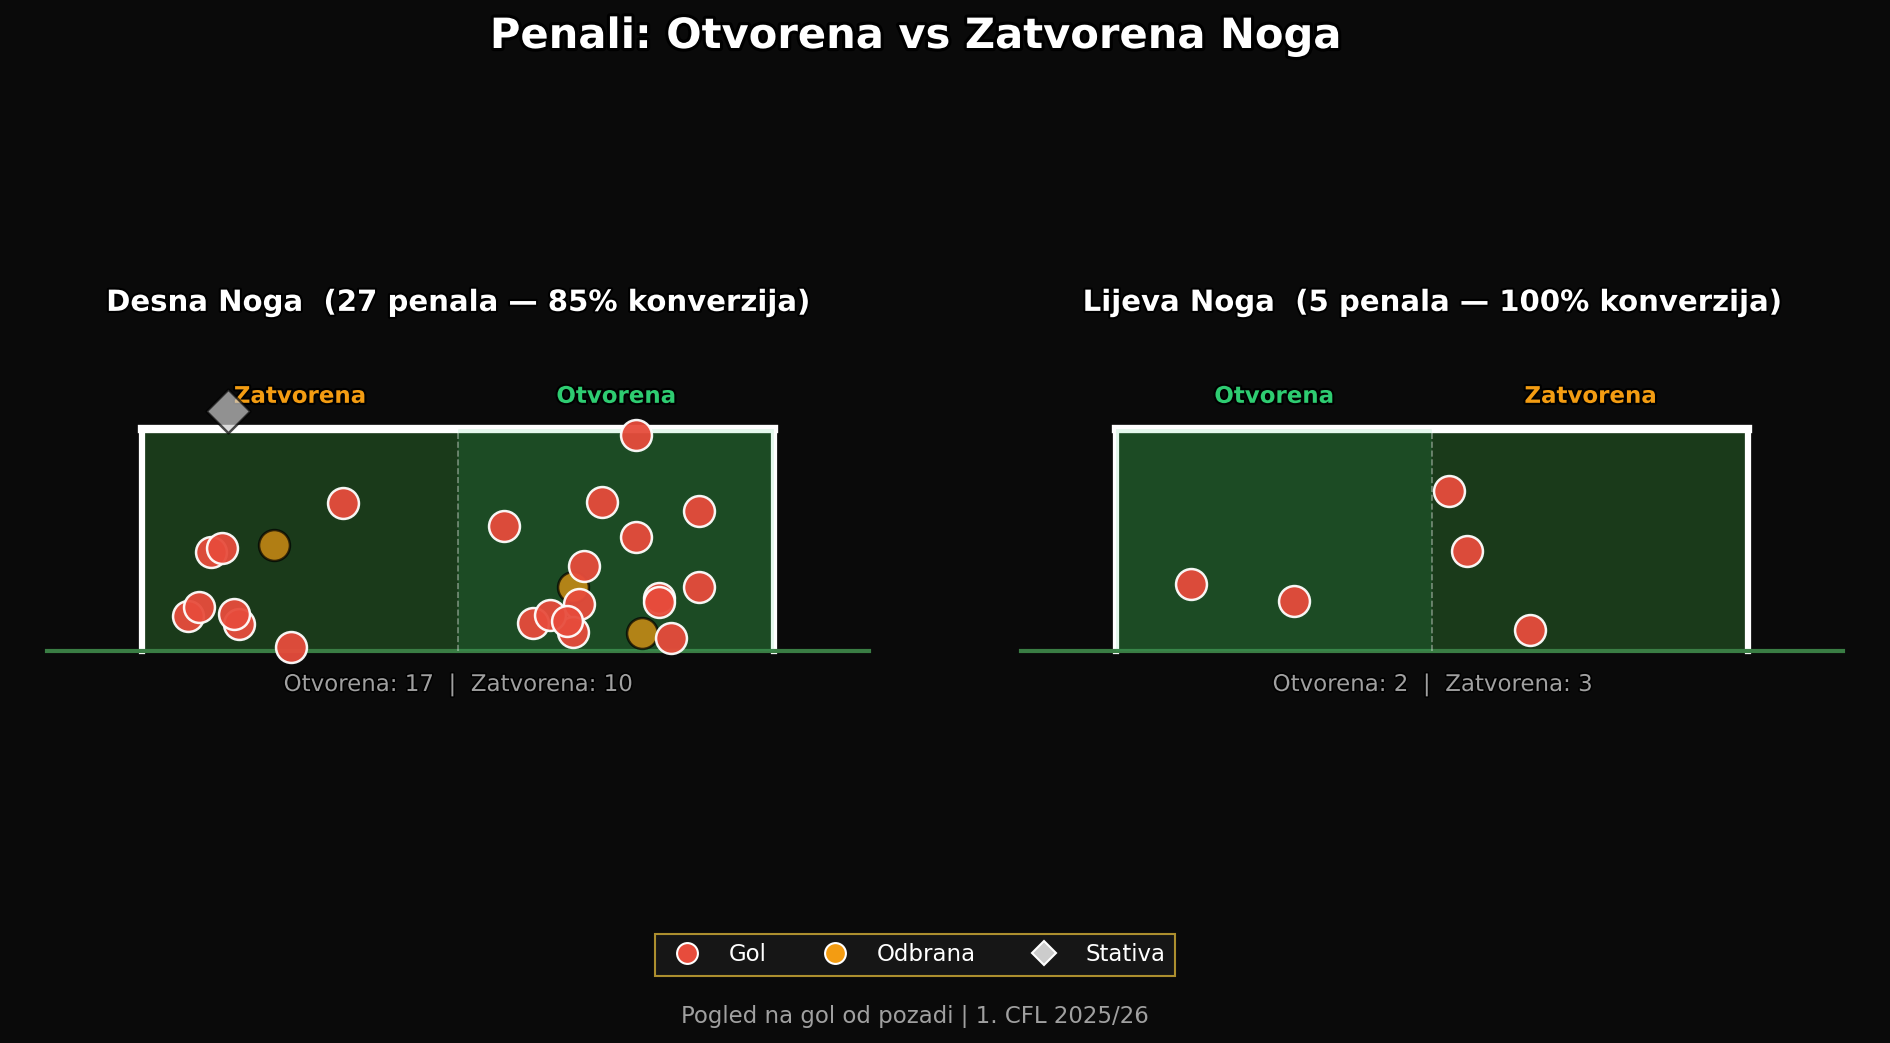

In [10]:
# ─── Figure: Penalty Placement by Preferred Foot ─────────────
from matplotlib.lines import Line2D

RIGHT_COLOR = '#e74c3c'
LEFT_COLOR  = '#3498db'

foot_groups = [
    ('Right', 'Desna Noga', RIGHT_COLOR),
    ('Left',  'Lijeva Noga', LEFT_COLOR),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)

for ax, (foot, label, accent) in zip(axes, foot_groups):
    ax.set_facecolor(NET_COLOR)
    draw_goal_frame(ax, lw=2)

    sub = pens[pens['preferredFoot'] == foot]

    # Shade the "natural / open" half of the goal
    if foot == 'Right':
        # Open = high gm_y (right side of plot)
        ax.add_patch(mpatches.Rectangle((50, 0), 50, 100, alpha=0.12, facecolor=GREEN, zorder=2))
        ax.text(75, 112, 'Otvorena', fontsize=11, color=GREEN, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
        ax.text(25, 112, 'Zatvorena', fontsize=11, color=SAVE_ORANGE, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
    else:
        # Open = low gm_y (left side of plot)
        ax.add_patch(mpatches.Rectangle((0, 0), 50, 100, alpha=0.12, facecolor=GREEN, zorder=2))
        ax.text(25, 112, 'Otvorena', fontsize=11, color=GREEN, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
        ax.text(75, 112, 'Zatvorena', fontsize=11, color=SAVE_ORANGE, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

    # Centre dashed line
    ax.plot([50, 50], [0, 100], color='white', linewidth=0.8, linestyle='--', alpha=0.4, zorder=3)

    # Plot each outcome
    for outcome in ['save', 'post', 'goal']:
        s = sub[sub['shotType'] == outcome]
        if len(s) == 0:
            continue
        marker = 'o' if outcome != 'post' else 'D'
        edge = 'white' if outcome == 'goal' else 'black'
        ax.scatter(
            s['gm_y'], s['gm_z'], s=220, c=OUTCOME_COLORS[outcome],
            marker=marker, edgecolors=edge, linewidth=1.2,
            alpha=0.95 if outcome == 'goal' else 0.7,
            zorder=6 if outcome == 'goal' else 4,
        )

    # Stats
    n_total = len(sub)
    n_goals = (sub['shotType'] == 'goal').sum()
    n_open  = (sub['kick_side'] == 'Otvorena').sum()
    n_closed = (sub['kick_side'] == 'Zatvorena').sum()
    conv = n_goals / n_total * 100 if n_total else 0

    t = ax.set_title(f'{label}  ({n_total} penala — {conv:.0f}% konverzija)',
                     fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=25)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

    ax.text(50, -10, f'Otvorena: {n_open}  |  Zatvorena: {n_closed}',
            fontsize=11, color=TEXT_GREY, ha='center', va='top',
            path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'), path_effects.Normal()])

# Shared legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=GOAL_RED,   markersize=10, label='Gol',     linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=SAVE_ORANGE, markersize=10, label='Odbrana', linestyle='None'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor=POST_COLOR,  markersize=8,  label='Stativa', linestyle='None'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=True,
           fancybox=False, fontsize=11, edgecolor=GOLD, facecolor='#1a1a1a',
           labelcolor=TEXT_WHITE, bbox_to_anchor=(0.5, -0.02))

suptitle = fig.suptitle('Penali: Otvorena vs Zatvorena Noga',
                         fontsize=20, fontweight='bold', color=TEXT_WHITE, y=1.06)
suptitle.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()])

fig.text(0.5, -0.06, 'Pogled na gol od pozadi | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

fig.subplots_adjust(wspace=0.10)
plt.savefig(FIGURES_DIR / 'penalty_foot_preference.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: penalty_foot_preference.png')
plt.show()

✅ Saved: gk_penalty_saves.png


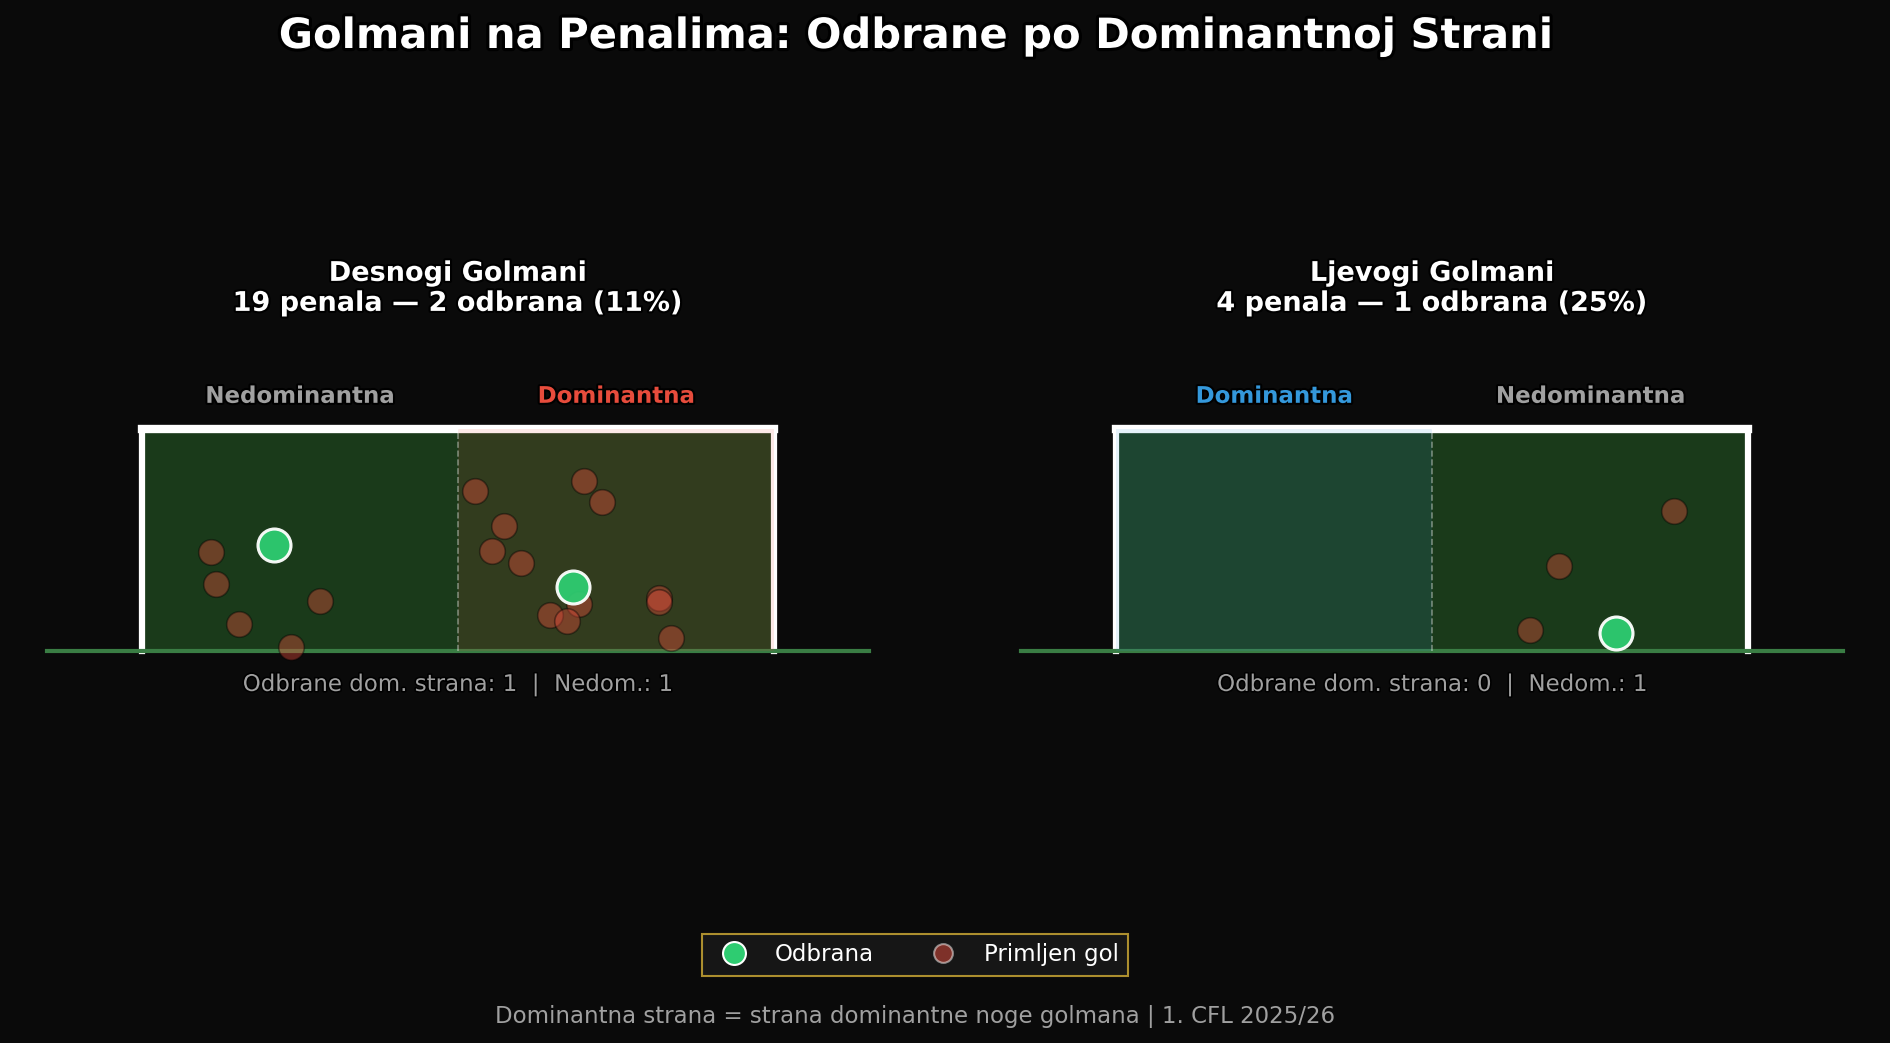

In [11]:
# ─── Figure: Goalkeeper Penalty Saves by Preferred Foot ──────

gk_foot_groups = [
    ('Right', 'Desnogi Golmani', RIGHT_COLOR),
    ('Left',  'Ljevogi Golmani', LEFT_COLOR),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)

for ax, (foot, label, accent) in zip(axes, gk_foot_groups):
    ax.set_facecolor(NET_COLOR)
    draw_goal_frame(ax, lw=2)

    # All penalties faced by GKs with this foot preference
    faced = pens[pens['gk_foot'] == foot]
    saves = faced[faced['shotType'] == 'save']
    conceded = faced[faced['shotType'] == 'goal']

    # Shade GK's dominant diving side
    if foot == 'Right':
        # GK right = high gm_y (right on plot)
        ax.add_patch(mpatches.Rectangle((50, 0), 50, 100, alpha=0.12, facecolor=accent, zorder=2))
        ax.text(75, 112, 'Dominantna', fontsize=11, color=accent, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
        ax.text(25, 112, 'Nedominantna', fontsize=11, color=TEXT_GREY, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
    else:
        # GK left = low gm_y (left on plot)
        ax.add_patch(mpatches.Rectangle((0, 0), 50, 100, alpha=0.12, facecolor=accent, zorder=2))
        ax.text(25, 112, 'Dominantna', fontsize=11, color=accent, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])
        ax.text(75, 112, 'Nedominantna', fontsize=11, color=TEXT_GREY, ha='center', fontweight='bold',
                path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

    # Centre dashed line
    ax.plot([50, 50], [0, 100], color='white', linewidth=0.8, linestyle='--', alpha=0.4, zorder=3)

    # Plot conceded goals (faded, background)
    if len(conceded) > 0:
        ax.scatter(conceded['gm_y'], conceded['gm_z'],
                   s=150, c=GOAL_RED, marker='o', edgecolors='black',
                   linewidth=0.8, alpha=0.4, zorder=4)

    # Plot saves (prominent)
    if len(saves) > 0:
        ax.scatter(saves['gm_y'], saves['gm_z'],
                   s=250, c=GREEN, marker='o', edgecolors='white',
                   linewidth=1.5, alpha=0.95, zorder=6)

    # Stats
    n_faced = len(faced)
    n_saved = len(saves)
    save_pct = n_saved / n_faced * 100 if n_faced else 0

    dom_saves = (saves['gk_dive'] == 'Dominantna').sum() if len(saves) else 0
    non_saves = (saves['gk_dive'] == 'Nedominantna').sum() if len(saves) else 0

    t = ax.set_title(f'{label}\n{n_faced} penala — {n_saved} odbrana ({save_pct:.0f}%)',
                     fontsize=13, fontweight='bold', color=TEXT_WHITE, pad=25)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

    ax.text(50, -10, f'Odbrane dom. strana: {dom_saves}  |  Nedom.: {non_saves}',
            fontsize=11, color=TEXT_GREY, ha='center', va='top',
            path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'), path_effects.Normal()])

# Shared legend
legend_gk = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=GREEN,    markersize=11, label='Odbrana',  linestyle='None'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=GOAL_RED, markersize=9,  label='Primljen gol', linestyle='None', alpha=0.5),
]
fig.legend(handles=legend_gk, loc='lower center', ncol=2, frameon=True,
           fancybox=False, fontsize=11, edgecolor=GOLD, facecolor='#1a1a1a',
           labelcolor=TEXT_WHITE, bbox_to_anchor=(0.5, -0.02))

suptitle = fig.suptitle('Golmani na Penalima: Odbrane po Dominantnoj Strani',
                         fontsize=20, fontweight='bold', color=TEXT_WHITE, y=1.06)
suptitle.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()])

fig.text(0.5, -0.06, 'Dominantna strana = strana dominantne noge golmana | 1. CFL 2025/26',
         fontsize=11, color=TEXT_GREY, ha='center')

fig.subplots_adjust(wspace=0.10)
plt.savefig(FIGURES_DIR / 'gk_penalty_saves.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print('✅ Saved: gk_penalty_saves.png')
plt.show()

✅ Saved: goals_by_preferred_foot.png  (261 goals: 215 right, 46 left)


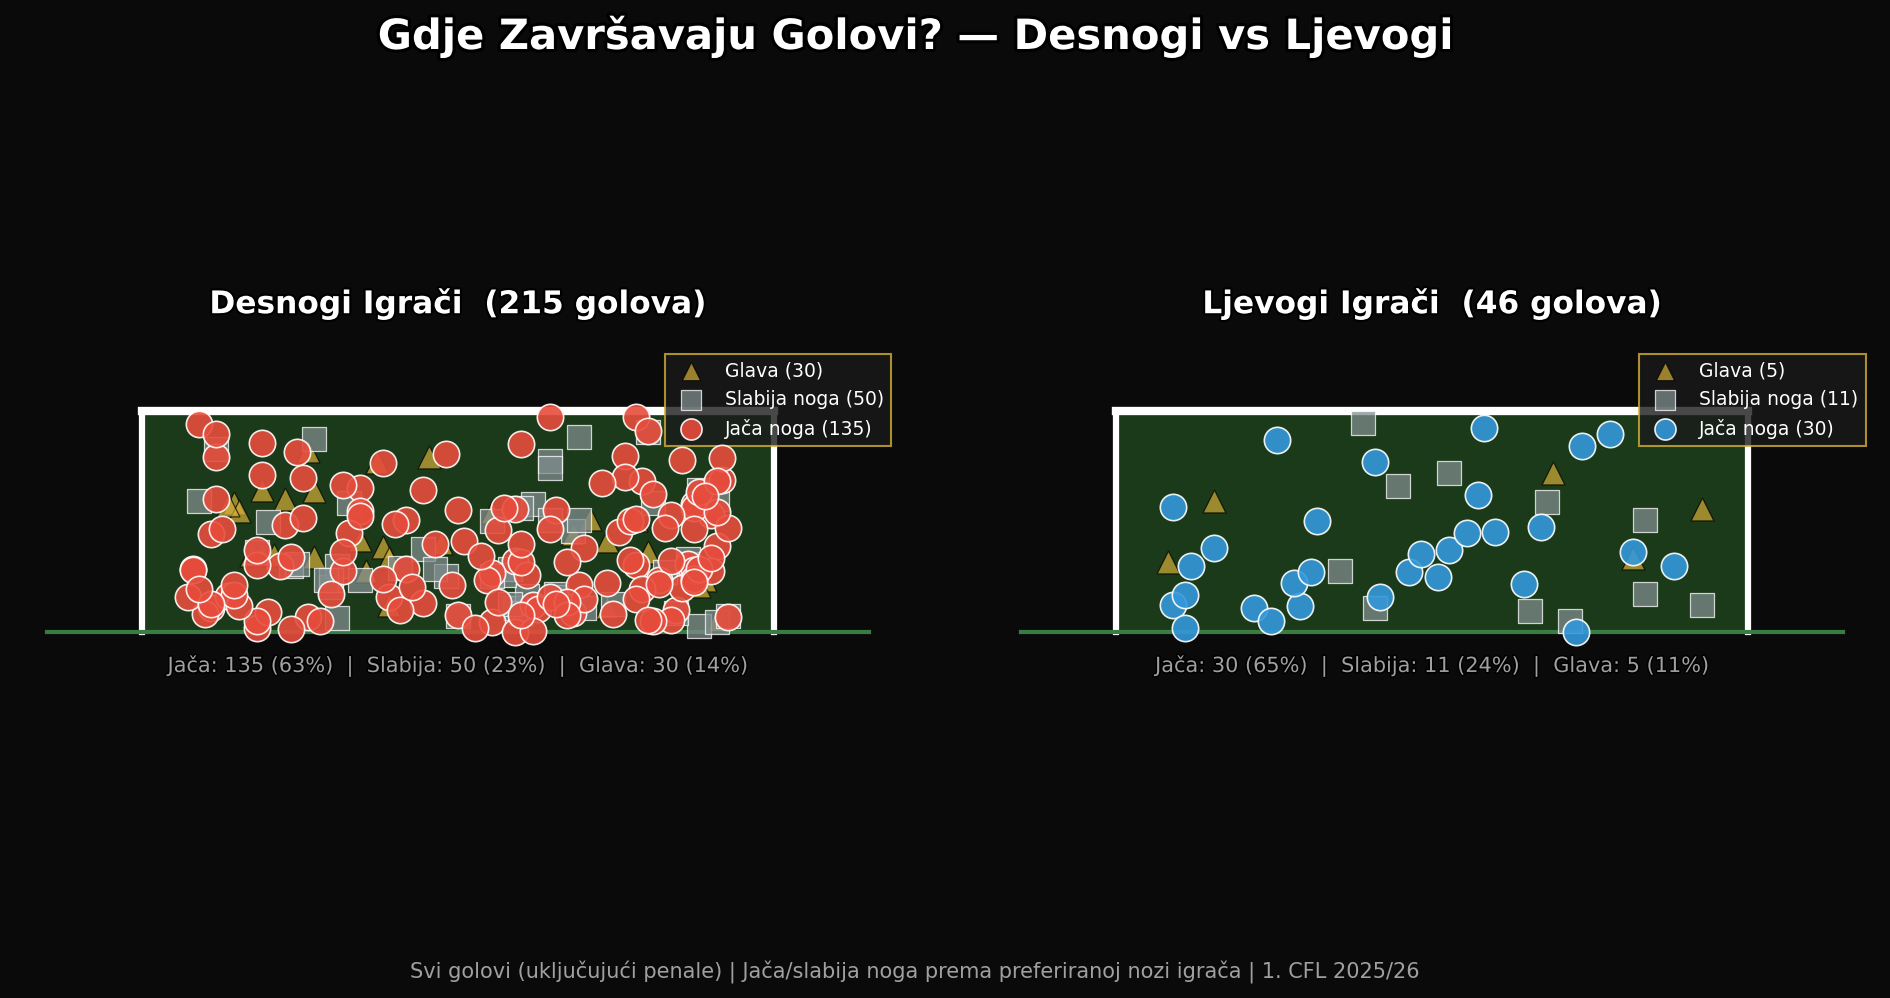

In [ ]:
# ─── Figure: Goal Zones by Preferred Foot (Right vs Left) ────
from matplotlib.colors import Normalize as MplNorm

shots_with_foot = shots.copy()
shots_with_foot['preferredFoot'] = shots_with_foot['player_id'].map(foot_map)

all_goals_foot = shots_with_foot[
    (shots_with_foot['shotType'] == 'goal') &
    (shots_with_foot['preferredFoot'].isin(['Right', 'Left']))
].copy()

# Zone grid: 3 cols × 3 rows
y_edges = [0, 33.3, 66.6, 100]
z_edges = [0, 33.3, 66.6, 100]
y_labels = ['Lijevo', 'Centar', 'Desno']
z_labels = ['Nisko', 'Sredina', 'Visoko']

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
fig.patch.set_facecolor(BG_COLOR)

for ax, (foot, label, accent) in zip(axes, [('Right', 'Desnogi Igrači', RIGHT_COLOR),
                                              ('Left',  'Ljevogi Igrači', LEFT_COLOR)]):
    ax.set_facecolor(NET_COLOR)
    draw_goal_frame(ax, lw=2)

    sub = all_goals_foot[all_goals_foot['preferredFoot'] == foot]
    # Clip to goal frame for zone assignment
    sub_in = sub[(sub['gm_y'] >= 0) & (sub['gm_y'] <= 100) &
                 (sub['gm_z'] >= 0) & (sub['gm_z'] <= 100)].copy()
    n_total = len(sub_in)

    sub_in['y_zone'] = pd.cut(sub_in['gm_y'], bins=y_edges, labels=y_labels, include_lowest=True)
    sub_in['z_zone'] = pd.cut(sub_in['gm_z'], bins=z_edges, labels=z_labels, include_lowest=True)

    zone_counts = (
        sub_in.groupby(['z_zone', 'y_zone'], observed=False)
        .size().reset_index(name='count')
    )
    zone_counts['pct'] = (zone_counts['count'] / n_total * 100).round(1) if n_total else 0

    # Separate strong/weak/head per zone
    if foot == 'Right':
        sub_in['_foot_type'] = sub_in['bodyPart'].map({'right-foot': 'Jača', 'left-foot': 'Slabija', 'head': 'Glava'})
    else:
        sub_in['_foot_type'] = sub_in['bodyPart'].map({'left-foot': 'Jača', 'right-foot': 'Slabija', 'head': 'Glava'})

    foot_zone = (
        sub_in.groupby(['z_zone', 'y_zone', '_foot_type'], observed=False)
        .size().reset_index(name='ft_count')
    )

    max_pct = zone_counts['pct'].max() if n_total else 1
    norm = MplNorm(vmin=0, vmax=max_pct + 5)
    # Use accent-tinted colormap
    from matplotlib.colors import LinearSegmentedColormap
    base_rgb = tuple(int(accent.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))
    cmap_foot = LinearSegmentedColormap.from_list('foot', [NET_COLOR, accent], N=256)

    for _, zrow in zone_counts.iterrows():
        yi = y_labels.index(zrow['y_zone'])
        zi = z_labels.index(zrow['z_zone'])
        x0, x1 = y_edges[yi], y_edges[yi + 1]
        z0, z1 = z_edges[zi], z_edges[zi + 1]
        w, h = x1 - x0, z1 - z0

        color = cmap_foot(norm(zrow['pct']))
        rect = mpatches.Rectangle((x0, z0), w, h, facecolor=color, alpha=0.7,
                                   edgecolor='white', linewidth=1.2, zorder=3)
        ax.add_patch(rect)

        cx, cz = x0 + w / 2, z0 + h / 2
        count = int(zrow['count'])
        pct = zrow['pct']

        if count > 0:
            # Main percentage
            t = ax.text(cx, cz + 8, f'{pct:.0f}%', fontsize=20, fontweight='bold',
                       color=TEXT_WHITE, ha='center', va='center', zorder=5)
            t.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'),
                                path_effects.Normal()])
            # Count
            t2 = ax.text(cx, cz - 8, f'{count} gol', fontsize=10,
                        color=TEXT_WHITE, ha='center', va='center', zorder=5, alpha=0.8)
            t2.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                                 path_effects.Normal()])

            # Body part breakdown (small text)
            ft_sub = foot_zone[(foot_zone['z_zone'] == zrow['z_zone']) &
                               (foot_zone['y_zone'] == zrow['y_zone']) &
                               (foot_zone['ft_count'] > 0)]
            parts = []
            for _, fr in ft_sub.iterrows():
                icon = {'Jača': '🦶', 'Slabija': '👟', 'Glava': '🗣️'}.get(fr['_foot_type'], '')
                parts.append(f"{icon}{int(fr['ft_count'])}")
            if parts:
                ax.text(cx, cz - 22, '  '.join(parts), fontsize=8,
                       color=TEXT_GREY, ha='center', va='center', zorder=5)

    # Title with total and strong/weak split
    n_strong = len(sub_in[sub_in['_foot_type'] == 'Jača'])
    n_weak   = len(sub_in[sub_in['_foot_type'] == 'Slabija'])
    n_head   = len(sub_in[sub_in['_foot_type'] == 'Glava'])

    t = ax.set_title(f'{label}  ({n_total} golova)',
                     fontsize=15, fontweight='bold', color=TEXT_WHITE, pad=15)
    t.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()])

    stat_txt = f'Jača: {n_strong} ({n_strong/n_total*100:.0f}%)  |  Slabija: {n_weak} ({n_weak/n_total*100:.0f}%)  |  Glava: {n_head} ({n_head/n_total*100:.0f}%)'
    ax.text(50, -10, stat_txt, fontsize=10, color=TEXT_GREY, ha='center', va='top',
            path_effects=[path_effects.Stroke(linewidth=1.5, foreground='black'), path_effects.Normal()])

suptitle = fig.suptitle('Gdje Završavaju Golovi? — Desnogi vs Ljevogi',
                         fontsize=20, fontweight='bold', color=TEXT_WHITE, y=1.04)
suptitle.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()])

fig.text(0.5, -0.03, 'Distribucija golova po zonama gola | % = udio golova u zoni | 1. CFL 2025/26',
         fontsize=10, color=TEXT_GREY, ha='center')

fig.subplots_adjust(wspace=0.10)
plt.savefig(FIGURES_DIR / 'goals_by_preferred_foot.png', dpi=300, facecolor=BG_COLOR, bbox_inches='tight')
print(f'✅ Saved: goals_by_preferred_foot.png  ({len(all_goals_foot)} goals: {(all_goals_foot["preferredFoot"]=="Right").sum()} right, {(all_goals_foot["preferredFoot"]=="Left").sum()} left)')
plt.show()